In [58]:
# Cell 1: import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_iris

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

In [3]:
def _show(image, ax):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

def show_encoding(img_1, img_2):
    ax1 = plt.subplot(1, 2, 1)
    _show(img_1, ax1)

    ax2 = plt.subplot(1, 2, 2)
    _show(img_2, ax2)
    
    plt.show()

In [4]:
# Load dataset
with np.load("../data/mnist.npz") as data:
    x_train_raw, y_train = data["x_train"], data["y_train"]
    x_test_raw, y_test = data["x_test"], data["y_test"]

# Preprocess for training
x_train = x_train_raw.reshape(-1, 28, 28, 1)/255.00
x_test  = x_test_raw.reshape(-1, 28, 28, 1)/255.00

In [45]:
latent_dim = 32

In [46]:
# Cell 2
encoder_input = layers.Input(shape=(28,28,1))

x = layers.Conv2D(32,3,activation='relu',padding='same')(encoder_input)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Flatten()(x)
x = layers.Dense(128,activation='relu')(x)

latent = layers.Dense(latent_dim, activation="linear")(x)

encoder = models.Model(encoder_input, latent)

In [47]:
decoder_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(128,activation='relu')(decoder_input)
x = layers.Dense(7*7*64,activation='relu')(x)

x = layers.Reshape((7,7,64))(x)

x = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)
x = layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(x)

decoder_output = layers.Conv2D(1,3,padding='same',activation='sigmoid')(x)

decoder = models.Model(decoder_input, decoder_output)


In [48]:
# Cell 4
autoencoder_input = encoder_input
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = models.Model(autoencoder_input, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [50]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=1,
    batch_size=64,
    validation_split=0.1
)

844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8132 - loss: 0.0933 - val_accuracy: 0.8143 - val_loss: 0.0867


In [11]:
autoencoder.save("../models/autoencoder_32D.keras")
encoder.save("../models/encoder_32D.keras")

In [51]:
autoencoder = load_model("../models/autoencoder_32D.keras")
encoder = load_model("../models/encoder_32D.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


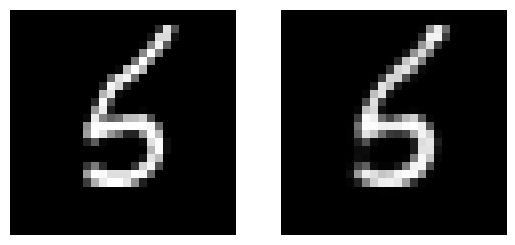

In [73]:
seed = np.random.randint(0, 60000)
img = x_train[seed].reshape(-1, 28, 28, 1)
pre_img = autoencoder.predict(img)
show_encoding(img.reshape(28, 28), pre_img.reshape(28, 28))

In [54]:
latent_space = encoder.predict(x_train)

print(latent_space.shape)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
(60000, 32)


In [55]:
pca = PCA(n_components=2)

latent_2d = pca.fit_transform(latent_space)

print(latent_2d.shape)


(60000, 2)


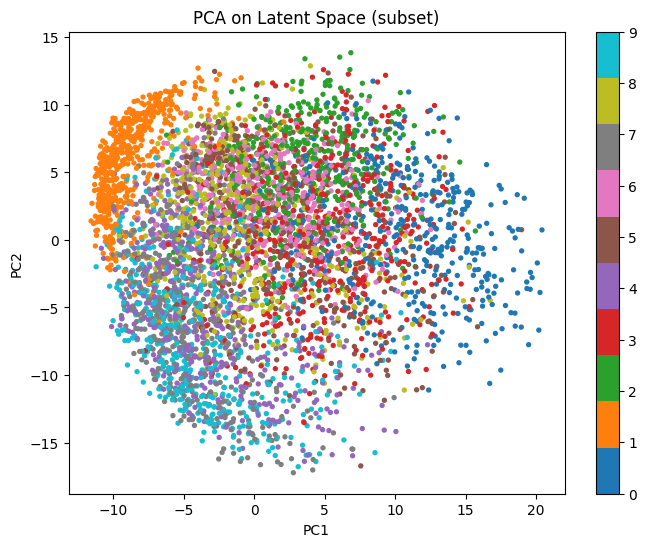

In [56]:
import numpy as np

idx = np.random.choice(len(latent_2d), 5000, replace=False)

plt.figure(figsize=(8,6))
plt.scatter(
    latent_2d[idx,0],
    latent_2d[idx,1],
    c=y_train[idx],
    cmap="tab10",
    s=8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA on Latent Space (subset)")
plt.colorbar()
plt.show()


In [61]:
tsne = TSNE(n_components=2, random_state=42)

latent_tsne = tsne.fit_transform(latent_space[:5000])


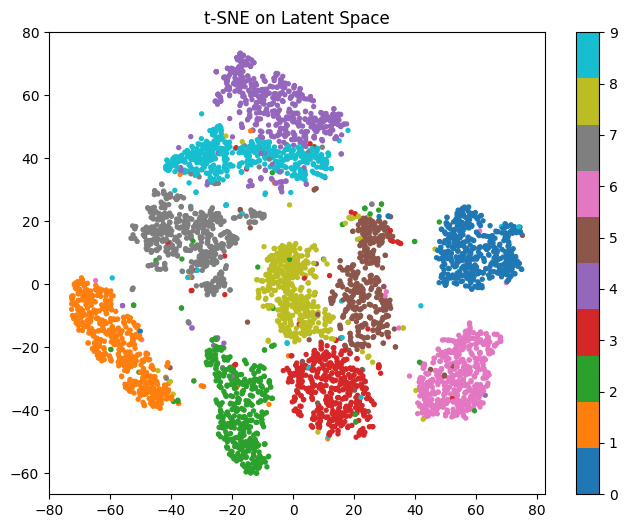

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(
    latent_tsne[:,0],
    latent_tsne[:,1],
    c=y_train[:5000],
    cmap="tab10",
    s=8
)

plt.title("t-SNE on Latent Space")
plt.colorbar()
plt.show()
